In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression

In [2]:
df=pd.read_csv('./breast_cancer.csv')

In [3]:
df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clump Thickness              683 non-null    int64
 1   Uniformity of Cell Size      683 non-null    int64
 2   Uniformity of Cell Shape     683 non-null    int64
 3   Marginal Adhesion            683 non-null    int64
 4   Single Epithelial Cell Size  683 non-null    int64
 5   Bare Nuclei                  683 non-null    int64
 6   Bland Chromatin              683 non-null    int64
 7   Normal Nucleoli              683 non-null    int64
 8   Mitoses                      683 non-null    int64
 9   Class                        683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


In [5]:
df['Class'].unique()

array([2, 4])

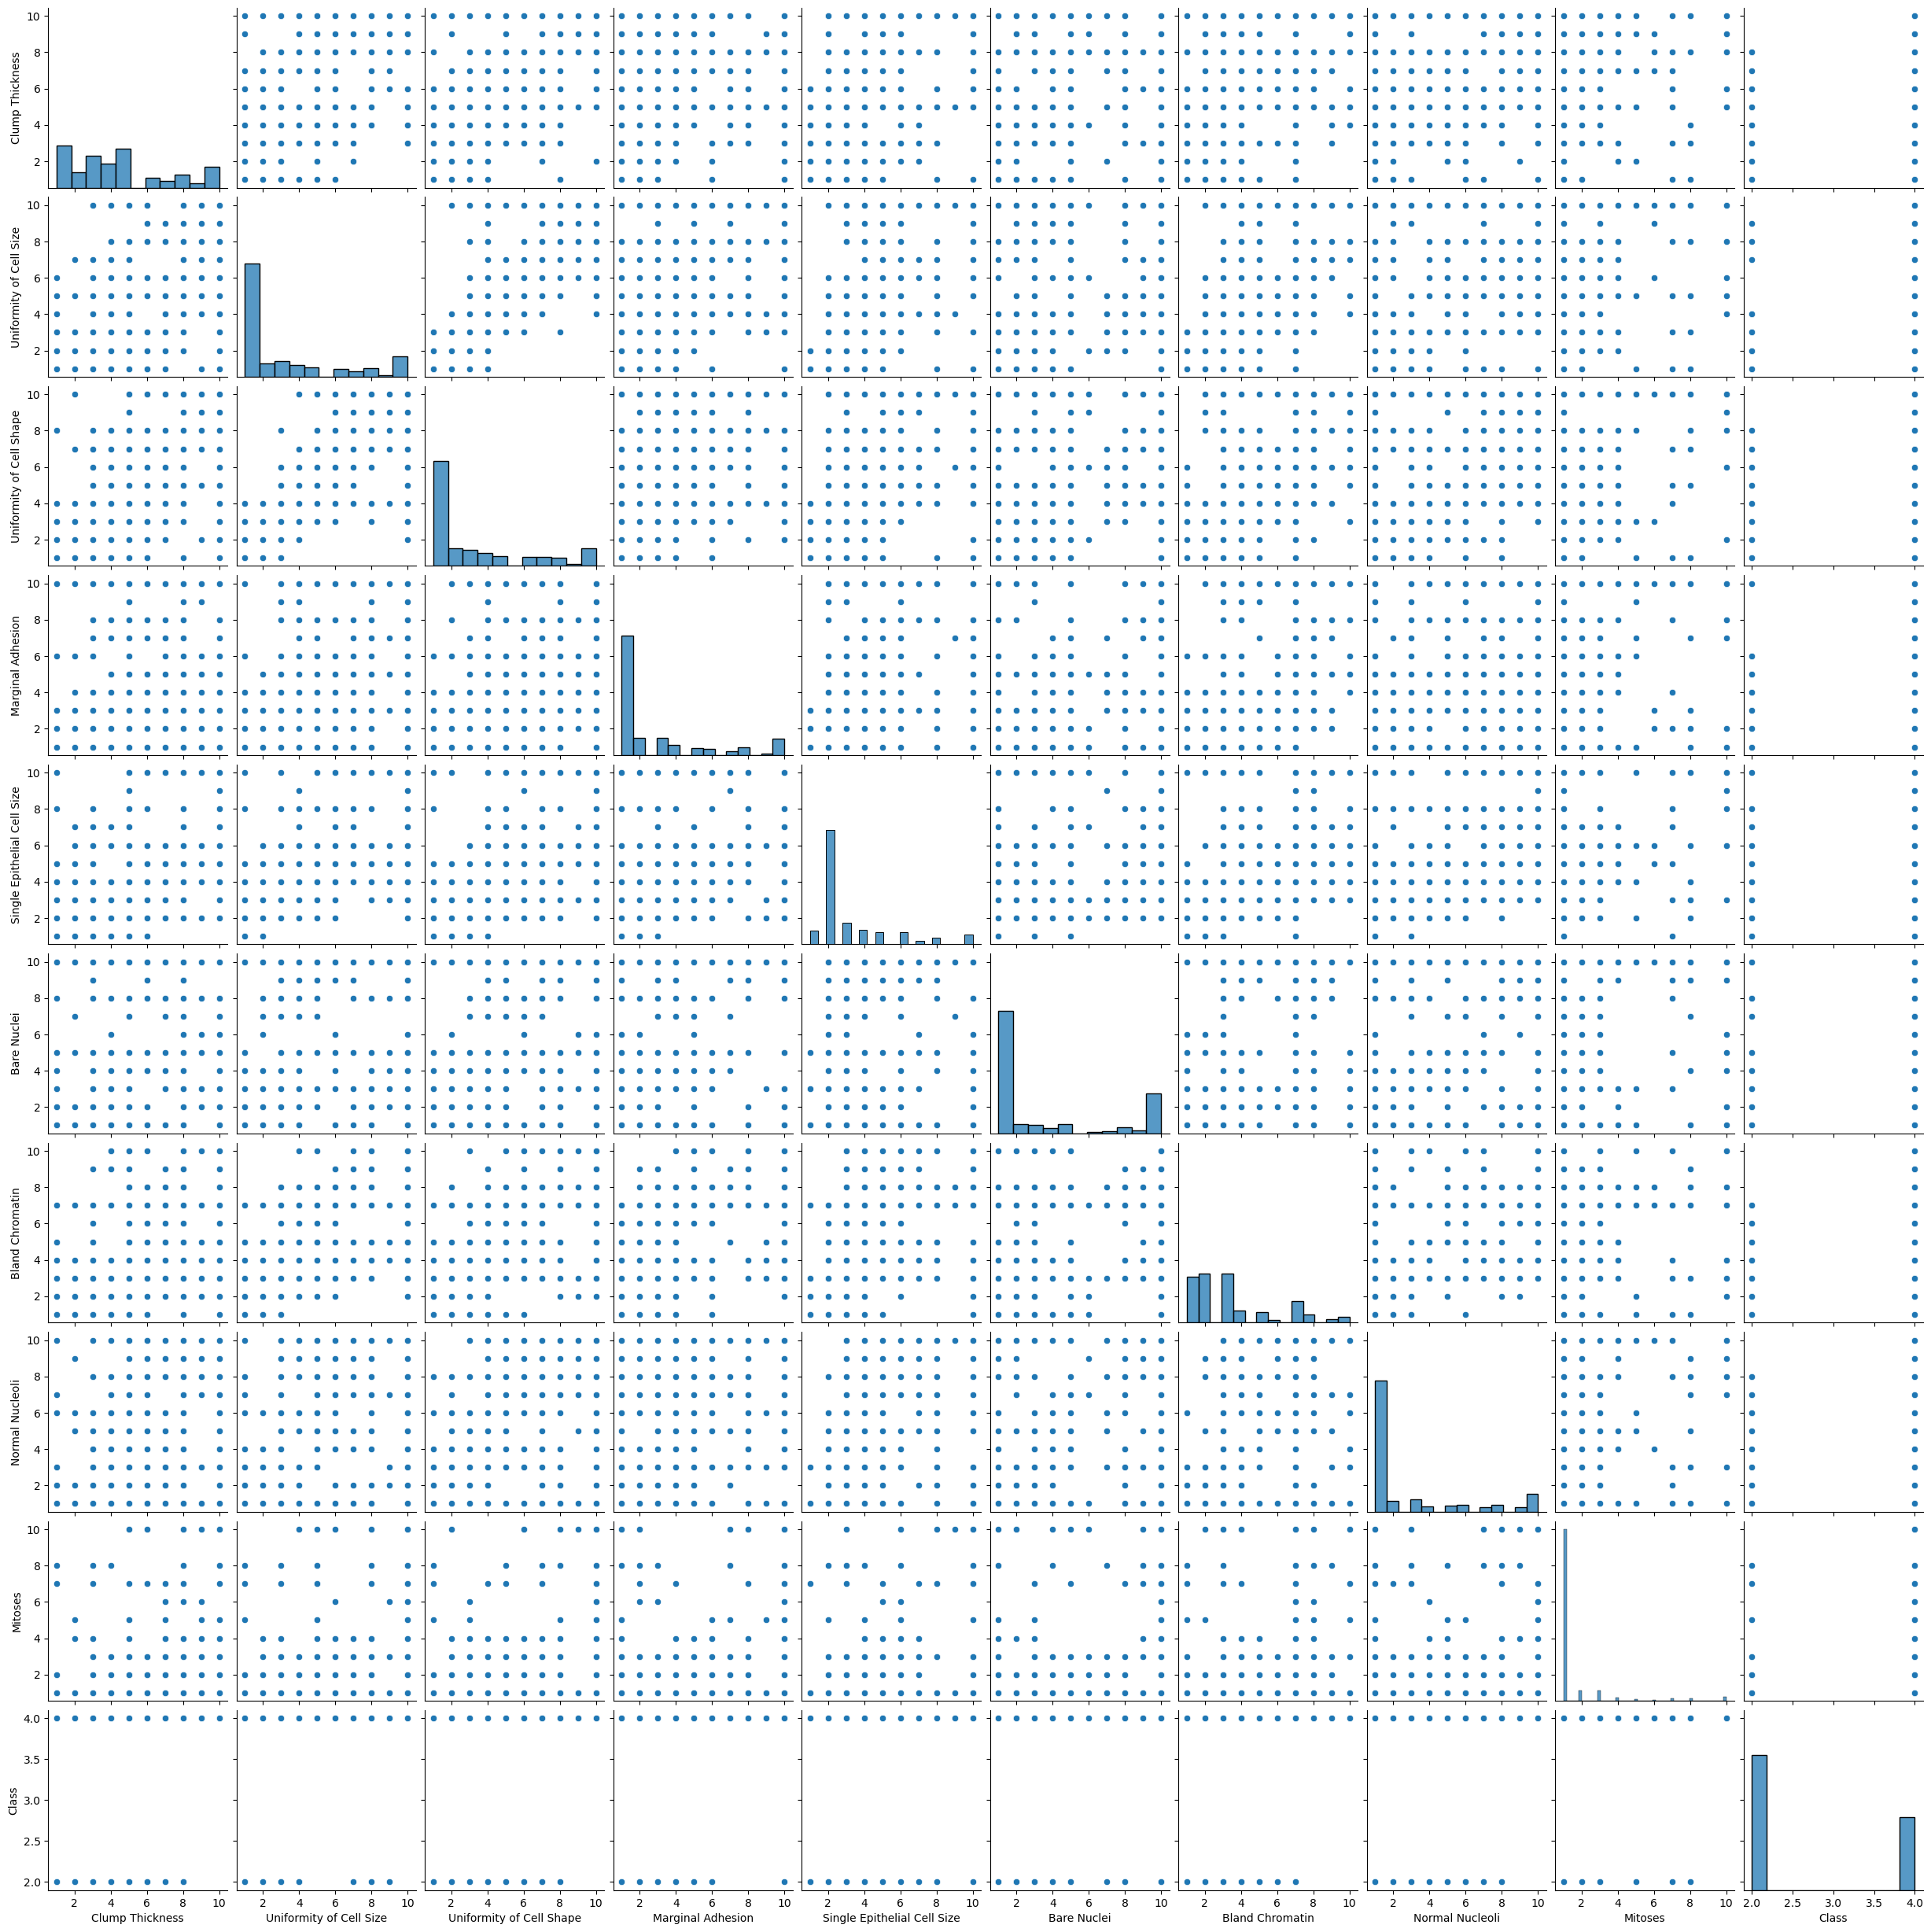

In [6]:
sns.pairplot(df)

In [7]:
x=df.drop('Class',axis=1)
y=df['Class']

In [8]:
xtrain,xtest,ytrain,ytest= train_test_split(x,y, test_size=0.2, random_state= 2)

In [9]:
log=LogisticRegression()
log

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
model=log.fit(xtrain,ytrain)
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
y_pred=model.predict(xtest)
y_pred[0:5]

array([4, 4, 2, 4, 2])

In [12]:
prediction= {}
prediction= pd.DataFrame(prediction)
prediction['Actual ytest']= ytest
prediction['predicted ytest']= y_pred
prediction.head()

,Actual ytest,predicted ytest
107,4,4
204,4,4
631,2,2
554,4,4
297,2,2


In [13]:
accuracy_score(ytest, y_pred)

0.9562043795620438

In [14]:
cn = confusion_matrix(ytest, y_pred)
cn

array([[79,  4],
       [ 2, 52]])

In [15]:
cn = pd.DataFrame(cn, columns= ['predicted 0', 'predicted 1'],
                 index = ['Actual 0', "Actual 1"])
cn

,predicted 0,predicted 1
Actual 0,79,4
Actual 1,2,52
